In [2]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 47.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 71.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 109.8 MB/s eta 0:00:0000:0100:01


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pennylane as qml
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt



# Quantum Circuit Definition with Angle Encoding and Parameterized Gates
def create_quantum_circuit(qubits):
    dev = qml.device('default.qubit', wires=qubits)

    @qml.qnode(dev)
    def circuit(input_data, params):
        # Ensure inputs are of correct length
        if len(input_data) != qubits:
            input_data = input_data[:qubits]  # Truncate if too long
            if len(input_data) < qubits:  # Pad if too short
                input_data = np.pad(input_data, (0, qubits - len(input_data)))


        if len(params) != qubits:
            params = np.random.rand(qubits)

        # Encode classical data into quantum state using angle encoding
        for i in range(qubits):
            qml.RY(input_data[i], wires=i)  # Apply Ry gates to input_data

        # Apply parameterized quantum gates to enhance the encoded state
        for i in range(qubits):
            qml.RX(params[i], wires=i)  # Apply Rx gate

        for i in range(qubits):
            qml.RZ(params[i] / 2, wires=i)  # Apply Rz gate

        return qml.probs(wires=range(qubits))  # Probabilities for each qubit

    return circuit

# Quantum Layer: This layer will scale the filters of a classical Conv2D
class QuantumConv2DLayer(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, qubits=4):
        super(QuantumConv2DLayer, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.qubits = qubits

        # Define quantum circuit
        self.circuit = create_quantum_circuit(qubits=qubits)

        # Learnable parameters for the quantum circuit
        self.param = nn.Parameter(torch.randn(self.qubits))

        # Initialize Conv2D layer with proper dimensions
        self.conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            padding=kernel_size//2
        )

    def forward(self, x):
        batch_size, channels, height, width = x.shape

        # Extract features from the input tensor to feed into quantum circuit
        # We'll take the average of each channel as a simple feature
        features = torch.mean(x, dim=[2, 3])  # Average across spatial dimensions
        features = features.mean(dim=0)  # Average across batch dimension

        # Ensure we have the right number of features for our quantum circuit
        features_trimmed = features[:self.qubits] if len(features) > self.qubits else features
        if len(features_trimmed) < self.qubits:
            # Pad with zeros if we don't have enough features
            padding = torch.zeros(self.qubits - len(features_trimmed), device=x.device)
            features_trimmed = torch.cat([features_trimmed, padding])

        features_np = features_trimmed.cpu().detach().numpy()

        params = self.param.detach().cpu().numpy()

        # Run the quantum circuit
        result = self.circuit(features_np, params)

        # Convert result to tensor and reshape for scaling
        result_tensor = torch.tensor(result, dtype=torch.float32, device=x.device)
        quantum_scale = result_tensor.mean()  # Use mean of quantum result as scale factor

        # Apply the standard convolution with weights scaled by quantum result
        # First, save the original weights
        original_weight = self.conv.weight.data.clone()

        # Scale the weights
        self.conv.weight.data = original_weight * quantum_scale

        # Apply the convolution
        output = self.conv(x)

        self.conv.weight.data = original_weight

        return output

# Building the Model
class QuantumCNN(nn.Module):
    def __init__(self, input_shape=(32, 32, 3), num_classes=10, qubits=8):
        super(QuantumCNN, self).__init__()

        # First Conv2D Layer
        self.conv1 = nn.Conv2d(in_channels=input_shape[2], out_channels=64, kernel_size=4, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.5)

        # Second Conv2D Layer
        self.conv2 = nn.Conv2d(64, 64, kernel_size=4, padding=1)
        self.dropout2 = nn.Dropout(0.25)

        # QuantumConv2D Layer (parameterized quantum circuits)
        self.qconv = QuantumConv2DLayer(in_channels=64, out_channels=64, kernel_size=3, qubits=qubits)

        # Calculate the size of flattened features after convolutions
        # After two max pooling with stride 2, the size is reduced to 1/4
        h_out = input_shape[0] // 4
        w_out = input_shape[1] // 4


        self.fc1 = nn.Linear(3136, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = self.dropout1(x)

        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout2(x)

        # QuantumConv2D Layer
        x = self.qconv(x)

        # Flatten the output for fully connected layer
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# Training Loop with Validation
def train(model, train_loader, val_loader, optimizer, criterion, epochs=10):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0

        # Training phase
        with tqdm(train_loader,desc=f'Epoch {epoch+1}/{epochs}',unit='batch') as tepoch:

            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                tepoch.set_postfix(train_loss=train_loss/len(tepoch), accuracy=100.*correct/total)



        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss/len(train_loader):.4f}, Accuracy: {100.*correct/total:.2f}%")

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            with tqdm(val_loader, desc=f"Validation Epoch {epoch+1}", unit="batch") as vepoch:

                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)

                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item()
                    _, predicted = torch.max(outputs, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()
                    vepoch.set_postfix(val_loss=val_loss/len(vepoch), accuracy=100.*correct/total)


        print(f"Epoch {epoch+1} - Validation Loss: {val_loss/len(val_loader):.4f}, Accuracy: {100.*correct/total:.2f}%")

# Test function

def test(model, test_loader):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    model.eval()
    correct = 0
    total = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    # Test Accuracy
    print(f"Test Accuracy: {100. * correct / total:.2f}%")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_predictions)
    print("Confusion Matrix:")
    print(cm)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_predictions))

    # F1 Score
    f1 = f1_score(all_labels, all_predictions, average='weighted')
    print(f"\nF1 Score: {f1:.4f}")

    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(10), yticklabels=np.arange(10))
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()



In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from collections import Counter

# Function to split the data based on provided class labels and data size
def create_data_splits(desired_classes, num_train_samples, num_test_samples, batch_size=32):
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

    # Load CIFAR-10 dataset
    full_train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    full_test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    # Filter the data by the desired classes
    train_indices = [i for i, label in enumerate(full_train_data.targets) if label in desired_classes]
    test_indices = [i for i, label in enumerate(full_test_data.targets) if label in desired_classes]

    # Create subsets based on the filtered indices
    train_subset = Subset(full_train_data, train_indices)
    test_subset = Subset(full_test_data, test_indices)

    # Extract the labels for train and test datasets
    train_labels = [full_train_data.targets[i] for i in train_subset.indices]
    test_labels = [full_test_data.targets[i] for i in test_subset.indices]

    # Ensure proportional splitting based on class labels for train and test datasets
    def get_stratified_samples(labels, total_samples):
        # Get the number of samples to select for each class
        class_counts = Counter(labels)
        proportions = {class_label: count / len(labels) for class_label, count in class_counts.items()}

        # Calculate the number of samples per class for the required total_samples
        samples_per_class = {class_label: int(proportion * total_samples) for class_label, proportion in proportions.items()}

        selected_indices = []
        for class_label, count in samples_per_class.items():
            # Get indices for this class
            class_indices = [i for i, label in enumerate(labels) if label == class_label]
            # Select the required number of samples
            selected_indices.extend(np.random.choice(class_indices, count, replace=False))

        return selected_indices

    # Get the indices for training and testing data based on the required size
    train_sample_indices = get_stratified_samples(train_labels, num_train_samples)
    test_sample_indices = get_stratified_samples(test_labels, num_test_samples)

    # Create new subsets with the selected samples
    train_dataset = Subset(train_subset, train_sample_indices)
    test_dataset = Subset(test_subset, test_sample_indices)

    # Split the train dataset further into training and validation using Stratified Sampling
    train_labels_selected = [train_labels[i] for i in train_sample_indices]
    sss_train = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)  # 80% train, 20% validation
    train_idx, val_idx = next(sss_train.split(np.zeros(len(train_labels_selected)), train_labels_selected))

    val_dataset = Subset(train_dataset, val_idx)

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

# Example usage
desired_classes = [0, 1, 2, 3, 4,5,6,7,8,9]  # Classes you want to use
num_train_samples = 50000  # Total number of samples to use for training
num_test_samples = 8000  # Total number of samples to use for testing

# Get the data loaders
train_loader, val_loader, test_loader = create_data_splits(desired_classes, num_train_samples, num_test_samples, batch_size=32)

print("Training data loader size:", len(train_loader.dataset))
print("Validation data loader size:", len(val_loader.dataset))
print("Test data loader size:", len(test_loader.dataset))


Files already downloaded and verified
Files already downloaded and verified
Training data loader size: 50000
Validation data loader size: 10000
Test data loader size: 8000


In [ ]:
model = QuantumCNN(input_shape=(32, 32, 3), num_classes=10, qubits=8)


optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()


batch_size = 32

train(model, train_loader, val_loader, optimizer, criterion, epochs=50)


Epoch 1/50:   0%|          | 0/1563 [00:25<?, ?batch/s, accuracy=41.6, train_loss=1.59]   


Epoch 1/50 - Train Loss: 1.5900, Accuracy: 41.57%


Validation Epoch 1:   0%|          | 0/313 [00:04<?, ?batch/s, accuracy=53.2, val_loss=1.3]    


Epoch 1 - Validation Loss: 1.2972, Accuracy: 53.21%


Epoch 2/50:   0%|          | 0/1563 [00:24<?, ?batch/s, accuracy=55.7, train_loss=1.24]    


...

Epoch 49 - Validation Loss: 0.0332, Accuracy: 99.01%


Epoch 50/50:   0%|          | 0/1563 [00:23<?, ?batch/s, accuracy=94.9, train_loss=0.145]   


Epoch 50/50 - Train Loss: 0.1454, Accuracy: 94.88%


Validation Epoch 50:   0%|          | 0/313 [00:03<?, ?batch/s, accuracy=99.4, val_loss=0.0212]  

Epoch 50 - Validation Loss: 0.0212, Accuracy: 99.38%


Test Accuracy: 76.54%
Confusion Matrix:
[[619  10  38   8  24   5   8   3  58  27]
 [ 12 696   6   5   2   3   8   3  27  38]
 [ 46   1 546  47  53  35  37  19  15   1]
 [ 22   3  64 446  54 127  41  23  16   4]
 [ 11   1  52  51 603  20  24  30   6   2]
 [ 10   2  39 141  26 530  13  26  11   2]
 [  4   3  34  49  34  12 655   3   3   3]
 [  9   4  23  25  51  30   2 641   6   9]
 [ 26  14   7   7   9   3   1   1 713  19]
 [ 19  42   3  12   6   3   8   9  24 674]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.78       800
           1       0.90      0.87      0.88       800
           2       0.67      0.68      0.68       800
           3       0.56      0.56      0.56       800
           4       0.70      0.75      0.73       800
           5       0.69      0.66      0.68       800
           6       0.82      0.82      0.82       800
           7       0.85      0.80      0.82       800
           8      

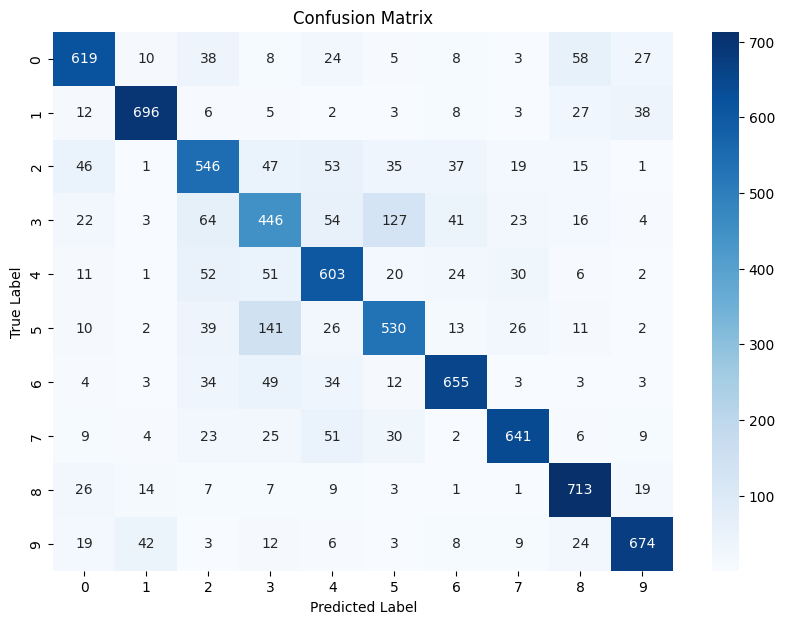

In [ ]:
# Test the model
test(model, test_loader)

Loading CIFAR-10 dataset with 5 selected classes...
Classes: Airplane, Automobile, Bird, Cat, Ship
Samples per class: 2500
Split: 70% train, 15% validation, 15% test


100%|██████████| 170M/170M [00:02<00:00, 78.8MB/s] 


Dataset created with 8750 train, 1875 val, 1875 test samples

Training Classical CNN


Classical CNN - Epoch 1/24:   0%|          | 0/274 [00:04<?, ?batch/s, accuracy=53.6, train_loss=1.13]  


Classical CNN - Epoch 1/24
Train Loss: 1.1296, Train Acc: 53.59%
Val Loss: 0.9087, Val Acc: 64.75%
Epoch Time: 4.65s
--------------------------------------------------


...

Quantum CNN (12 qubits) - Epoch 22/24
Train Loss: 0.6278, Train Acc: 75.87%
Val Loss: 0.7777, Val Acc: 69.28%
Epoch Time: 6.20s
--------------------------------------------------


Quantum CNN (12 qubits) - Epoch 23/24:   0%|          | 0/274 [00:05<?, ?batch/s, accuracy=76.7, train_loss=0.602]  


Quantum CNN (12 qubits) - Epoch 23/24
Train Loss: 0.6025, Train Acc: 76.66%
Val Loss: 0.7655, Val Acc: 69.49%
Epoch Time: 6.13s
--------------------------------------------------


Quantum CNN (12 qubits) - Epoch 24/24:   0%|          | 0/274 [00:05<?, ?batch/s, accuracy=76.5, train_loss=0.592]  


Quantum CNN (12 qubits) - Epoch 24/24
Train Loss: 0.5924, Train Acc: 76.49%
Val Loss: 0.7851, Val Acc: 68.53%
Epoch Time: 6.15s
--------------------------------------------------

Quantum CNN (12 qubits) Test Results:
Test Accuracy: 68.69%
Average Inference Time: 0.2622ms per image
F1 Score: 0.6838
Precision: 0.6852
Recall: 0.6869
Parameter Count: 910,033

Generating visualizations...


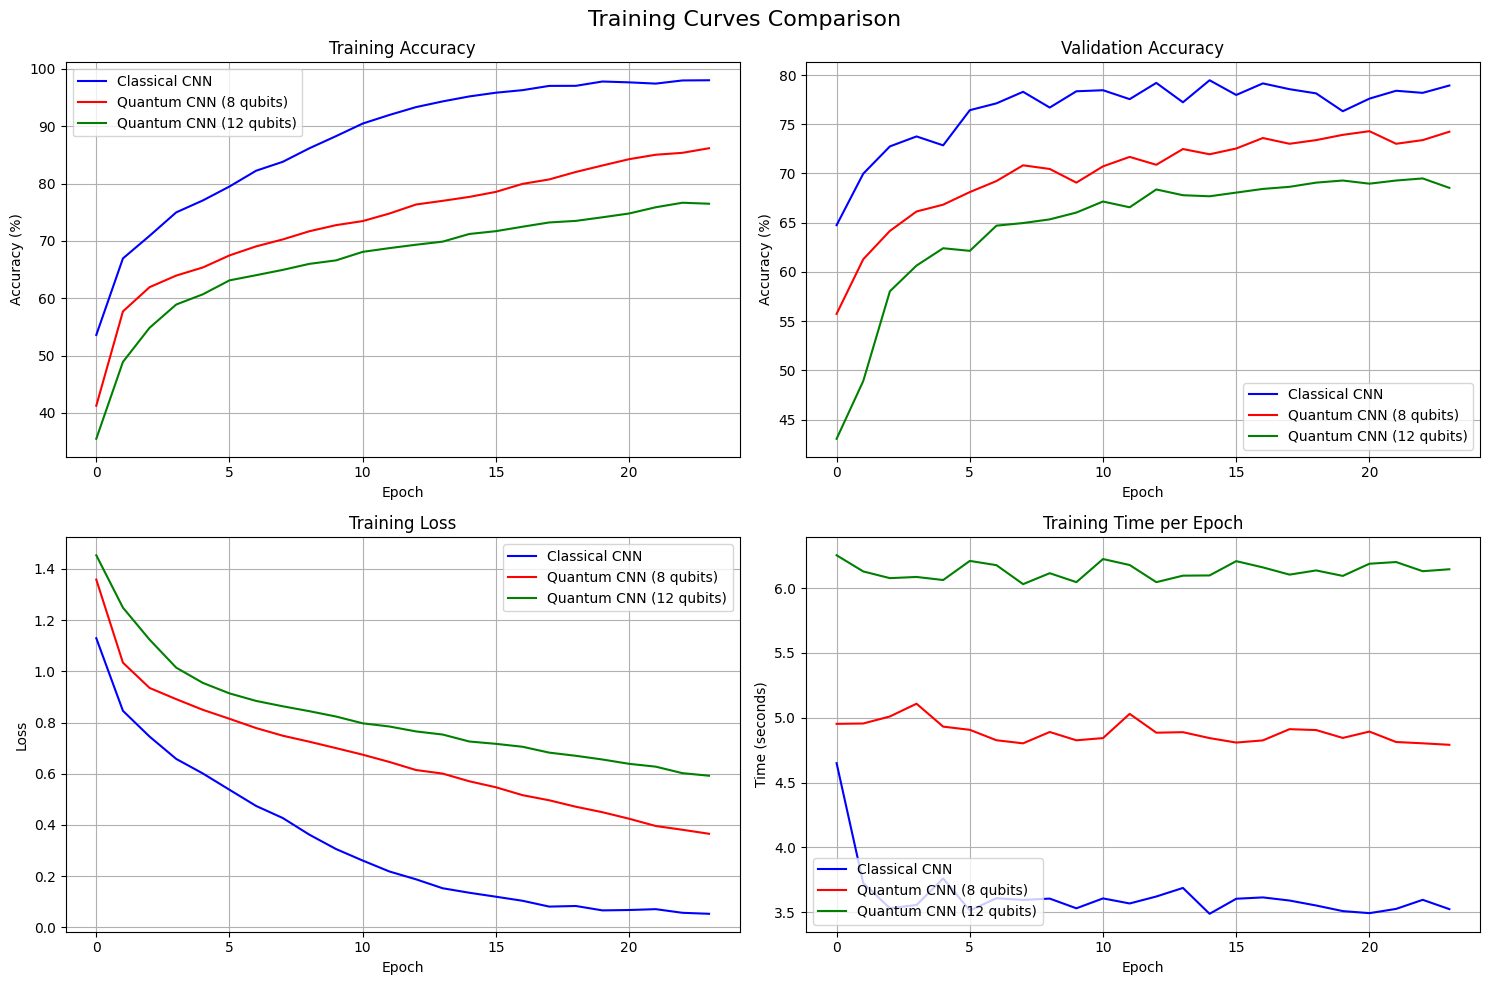

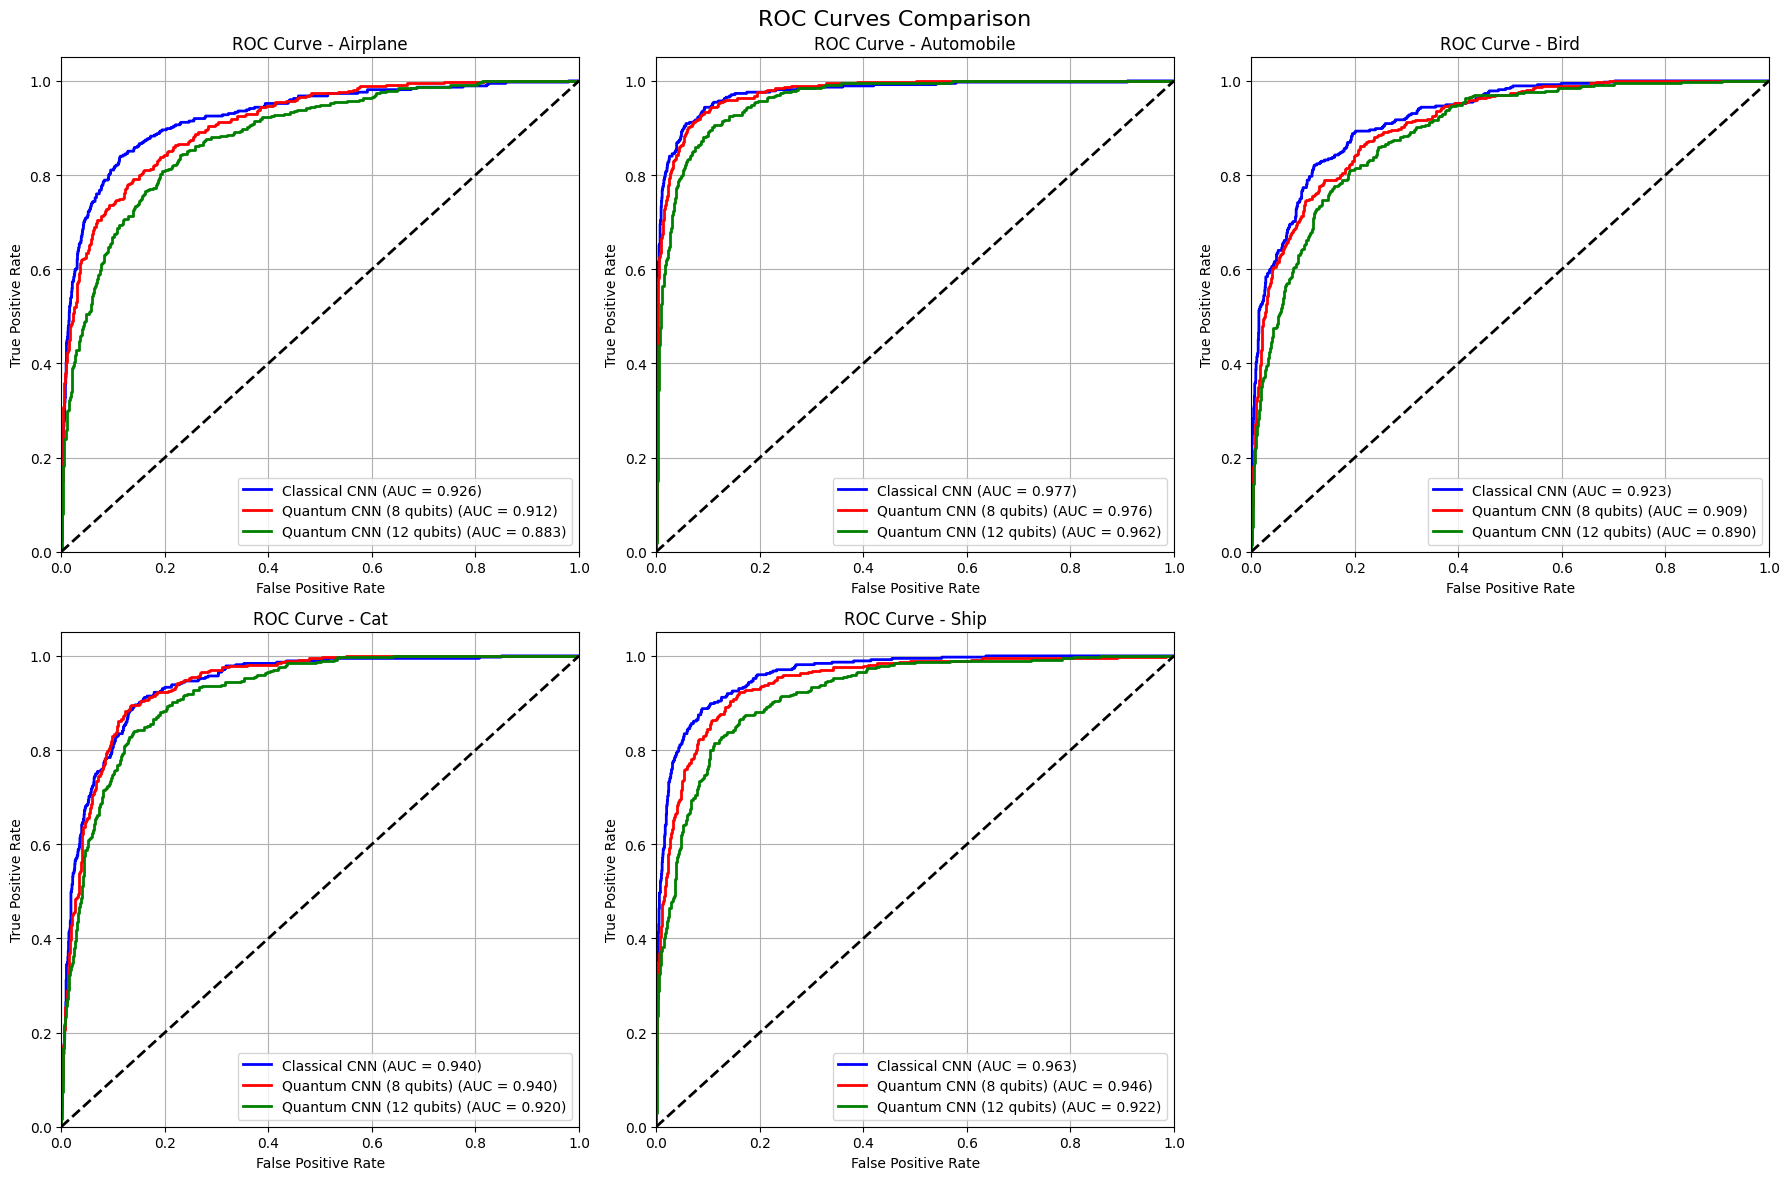

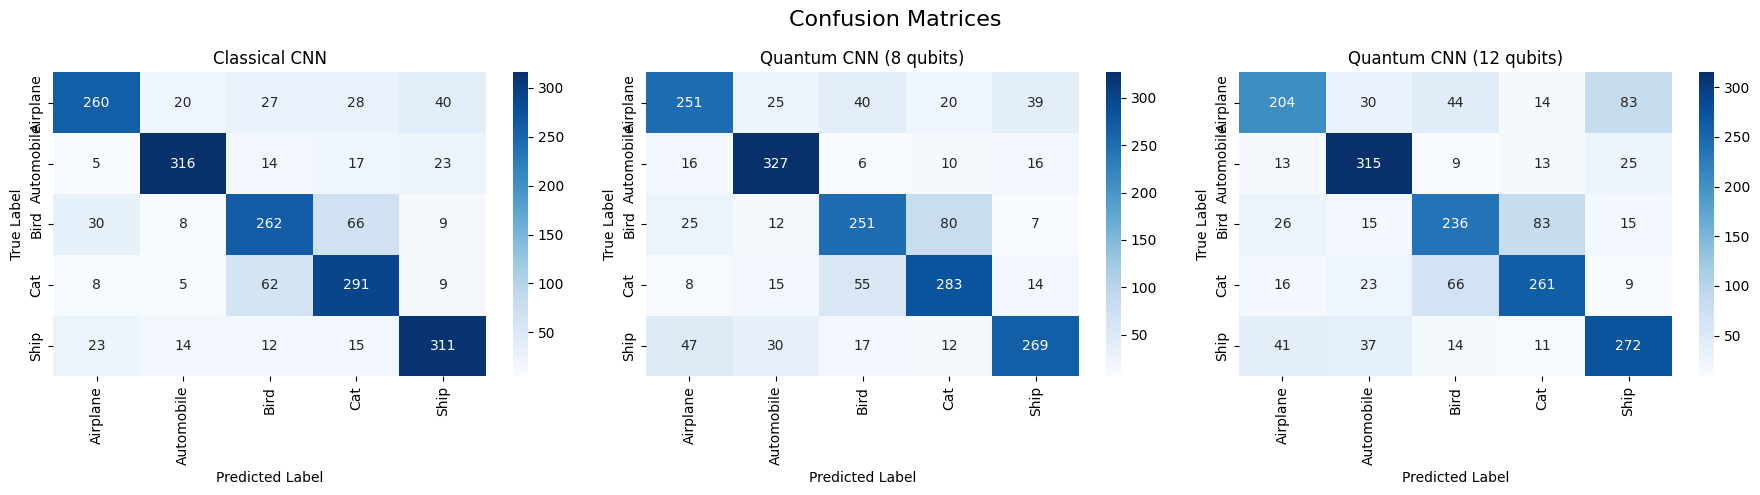


COMPREHENSIVE MODEL COMPARISON SUMMARY
                  Model Train Accuracy (%) Test Accuracy (%) F1 Score Precision Recall Parameters Total Training Time (s) Avg Epoch Time (s) Avg Inference Time (ms)
          Classical CNN              98.03             76.80   0.7682    0.7708 0.7680    910,021                   87.08               3.63                  0.0174
 Quantum CNN (8 qubits)              86.17             73.65   0.7354    0.7363 0.7365    910,029                  117.31               4.89                  0.1412
Quantum CNN (12 qubits)              76.49             68.69   0.6838    0.6852 0.6869    910,033                  147.19               6.13                  0.2622


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pennylane as qml
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset, Subset
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve, auc, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import time
from collections import Counter
import pandas as pd
from sklearn.preprocessing import label_binarize

# CIFAR-10 class mapping for the 5 selected classes
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
SELECTED_CLASSES = [0, 1, 2, 3, 8]  # Airplane, Automobile, Bird, Cat, Ship
CLASS_NAMES = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Ship']

# Function to create data splits for 5 selected classes with 2500 images per class
def create_data_splits_5_classes(desired_classes, samples_per_class=2500, batch_size=32):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # Load CIFAR-10 dataset
    full_train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    full_test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    # Filter and sample exactly 2500 images per class
    selected_indices = []
    selected_labels = []
    
    for class_idx in desired_classes:
        # Get all indices for this class from training data
        class_indices = [i for i, label in enumerate(full_train_data.targets) if label == class_idx]
        
        # Sample exactly 2500 images for this class
        if len(class_indices) >= samples_per_class:
            sampled_indices = np.random.choice(class_indices, samples_per_class, replace=False)
        else:
            # If not enough samples, use all available and sample with replacement
            sampled_indices = np.random.choice(class_indices, samples_per_class, replace=True)
        
        selected_indices.extend(sampled_indices)
        selected_labels.extend([class_idx] * samples_per_class)

    # Create subset with selected indices
    dataset_subset = Subset(full_train_data, selected_indices)
    
    # Remap labels to 0-4 for 5-class classification
    label_mapping = {old_label: new_label for new_label, old_label in enumerate(desired_classes)}
    remapped_labels = [label_mapping[label] for label in selected_labels]
    
    # Split: 70% train, 15% validation, 15% test
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)  # 70% train, 30% temp
    train_idx, temp_idx = next(sss1.split(np.zeros(len(remapped_labels)), remapped_labels))
    
    temp_labels = [remapped_labels[i] for i in temp_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)  # Split temp 50-50 for val and test
    val_idx_temp, test_idx_temp = next(sss2.split(np.zeros(len(temp_labels)), temp_labels))
    
    # Map back to original indices
    val_idx = [temp_idx[i] for i in val_idx_temp]
    test_idx = [temp_idx[i] for i in test_idx_temp]
    
    # Create datasets with custom label mapping
    class MappedDataset(Dataset):
        def __init__(self, original_dataset, indices, label_mapping):
            self.original_dataset = original_dataset
            self.indices = indices
            self.label_mapping = label_mapping
            
        def __len__(self):
            return len(self.indices)
            
        def __getitem__(self, idx):
            original_idx = self.indices[idx]
            data, original_label = self.original_dataset[original_idx]
            mapped_label = self.label_mapping[original_label]
            return data, mapped_label

    train_dataset = MappedDataset(dataset_subset, train_idx, label_mapping)
    val_dataset = MappedDataset(dataset_subset, val_idx, label_mapping)
    test_dataset = MappedDataset(dataset_subset, test_idx, label_mapping)

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"Dataset created with {len(train_dataset)} train, {len(val_dataset)} val, {len(test_dataset)} test samples")
    return train_loader, val_loader, test_loader

# Quantum Circuit Definition with Angle Encoding and Parameterized Gates
def create_quantum_circuit(qubits):
    dev = qml.device('default.qubit', wires=qubits)

    @qml.qnode(dev)
    def circuit(input_data, params):
        # Ensure inputs are of correct length
        if len(input_data) != qubits:
            input_data = input_data[:qubits]  # Truncate if too long
            if len(input_data) < qubits:  # Pad if too short
                input_data = np.pad(input_data, (0, qubits - len(input_data)))

        if len(params) != qubits:
            params = np.random.rand(qubits)

        # Encode classical data into quantum state using angle encoding
        for i in range(qubits):
            qml.RY(input_data[i], wires=i)  # Apply Ry gates to input_data

        # Apply parameterized quantum gates to enhance the encoded state
        for i in range(qubits):
            qml.RX(params[i], wires=i)  # Apply Rx gate

        for i in range(qubits):
            qml.RZ(params[i] / 2, wires=i)  # Apply Rz gate

        return qml.probs(wires=range(qubits))  # Probabilities for each qubit

    return circuit

# Quantum Layer: This layer will scale the filters of a classical Conv2D
class QuantumConv2DLayer(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, qubits=4):
        super(QuantumConv2DLayer, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.qubits = qubits

        # Define quantum circuit
        self.circuit = create_quantum_circuit(qubits=qubits)

        # Learnable parameters for the quantum circuit
        self.param = nn.Parameter(torch.randn(self.qubits))

        # Initialize Conv2D layer with proper dimensions
        self.conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            padding=kernel_size//2
        )

    def forward(self, x):
        batch_size, channels, height, width = x.shape

        # Extract features from the input tensor to feed into quantum circuit
        # We'll take the average of each channel as a simple feature
        features = torch.mean(x, dim=[2, 3])  # Average across spatial dimensions
        features = features.mean(dim=0)  # Average across batch dimension

        # Ensure we have the right number of features for our quantum circuit
        features_trimmed = features[:self.qubits] if len(features) > self.qubits else features
        if len(features_trimmed) < self.qubits:
            # Pad with zeros if we don't have enough features
            padding = torch.zeros(self.qubits - len(features_trimmed), device=x.device)
            features_trimmed = torch.cat([features_trimmed, padding])

        features_np = features_trimmed.cpu().detach().numpy()
        params = self.param.detach().cpu().numpy()

        # Run the quantum circuit
        result = self.circuit(features_np, params)

        # Convert result to tensor and reshape for scaling
        result_tensor = torch.tensor(result, dtype=torch.float32, device=x.device)
        quantum_scale = result_tensor.mean()  # Use mean of quantum result as scale factor

        # Apply the standard convolution with weights scaled by quantum result
        # First, save the original weights
        original_weight = self.conv.weight.data.clone()

        # Scale the weights
        self.conv.weight.data = original_weight * quantum_scale

        # Apply the convolution
        output = self.conv(x)

        self.conv.weight.data = original_weight

        return output

# Classical CNN Model (Baseline)
class ClassicalCNN(nn.Module):
    def __init__(self, input_shape=(32, 32, 3), num_classes=5):
        super(ClassicalCNN, self).__init__()

        # First Conv2D Layer
        self.conv1 = nn.Conv2d(in_channels=input_shape[2], out_channels=64, kernel_size=4, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.5)

        # Second Conv2D Layer
        self.conv2 = nn.Conv2d(64, 64, kernel_size=4, padding=1)
        self.dropout2 = nn.Dropout(0.25)

        # Third Conv2D Layer (replacing quantum layer with classical)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(3136, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = self.dropout1(x)

        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout2(x)

        # Third Conv2D Layer
        x = F.relu(self.conv3(x))

        # Flatten the output for fully connected layer
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# Quantum CNN Model
class QuantumCNN(nn.Module):
    def __init__(self, input_shape=(32, 32, 3), num_classes=5, qubits=8):
        super(QuantumCNN, self).__init__()

        # First Conv2D Layer
        self.conv1 = nn.Conv2d(in_channels=input_shape[2], out_channels=64, kernel_size=4, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.5)

        # Second Conv2D Layer
        self.conv2 = nn.Conv2d(64, 64, kernel_size=4, padding=1)
        self.dropout2 = nn.Dropout(0.25)

        # QuantumConv2D Layer (parameterized quantum circuits)
        self.qconv = QuantumConv2DLayer(in_channels=64, out_channels=64, kernel_size=3, qubits=qubits)

        self.fc1 = nn.Linear(3136, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = self.dropout1(x)

        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout2(x)

        # QuantumConv2D Layer
        x = self.qconv(x)

        # Flatten the output for fully connected layer
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# Enhanced Training Loop with comprehensive metrics
def train_with_metrics(model, train_loader, val_loader, optimizer, criterion, epochs=24, model_name="Model"):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    train_accuracies = []
    val_accuracies = []
    train_losses = []
    val_losses = []
    epoch_times = []

    total_start_time = time.time()

    for epoch in range(epochs):
        epoch_start_time = time.time()
        
        # Training phase
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0

        with tqdm(train_loader, desc=f'{model_name} - Epoch {epoch+1}/{epochs}', unit='batch') as tepoch:
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                tepoch.set_postfix(train_loss=train_loss/len(tepoch), accuracy=100.*correct/total)

        train_acc = 100. * correct / total
        train_accuracies.append(train_acc)
        train_losses.append(train_loss / len(train_loader))

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100. * correct / total
        val_accuracies.append(val_acc)
        val_losses.append(val_loss / len(val_loader))

        epoch_time = time.time() - epoch_start_time
        epoch_times.append(epoch_time)

        print(f"{model_name} - Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_acc:.2f}%")
        print(f"Epoch Time: {epoch_time:.2f}s")
        print("-" * 50)

    total_training_time = time.time() - total_start_time

    return {
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'epoch_times': epoch_times,
        'total_training_time': total_training_time,
        'avg_epoch_time': np.mean(epoch_times)
    }

# Comprehensive test function with all metrics
def comprehensive_test(model, test_loader, model_name="Model"):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    correct = 0
    total = 0
    all_labels = []
    all_predictions = []
    all_probabilities = []
    inference_times = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Measure inference time
            start_time = time.time()
            outputs = model(inputs)
            inference_time = time.time() - start_time
            inference_times.extend([inference_time / len(inputs)] * len(inputs))
            
            probabilities = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    # Calculate metrics
    test_accuracy = 100. * correct / total
    avg_inference_time = np.mean(inference_times)
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_predictions)
    
    # Classification Report
    precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_predictions, average='weighted')
    
    # ROC Curves and AUC for each class
    y_test_binary = label_binarize(all_labels, classes=[0, 1, 2, 3, 4])
    y_prob = np.array(all_probabilities)
    
    roc_data = {}
    for i in range(5):
        fpr, tpr, _ = roc_curve(y_test_binary[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        roc_data[CLASS_NAMES[i]] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc}

    # Parameter count
    param_count = sum(p.numel() for p in model.parameters())

    results = {
        'model_name': model_name,
        'test_accuracy': test_accuracy,
        'avg_inference_time': avg_inference_time,
        'confusion_matrix': cm,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_data': roc_data,
        'param_count': param_count,
        'all_labels': all_labels,
        'all_predictions': all_predictions
    }

    print(f"\n{model_name} Test Results:")
    print(f"Test Accuracy: {test_accuracy:.2f}%")
    print(f"Average Inference Time: {avg_inference_time*1000:.4f}ms per image")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Parameter Count: {param_count:,}")

    return results

# Visualization functions
def plot_training_curves(results_dict):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Training Curves Comparison', fontsize=16)

    colors = ['blue', 'red', 'green']
    models = list(results_dict.keys())

    # Training Accuracy
    for i, (model_name, results) in enumerate(results_dict.items()):
        axes[0, 0].plot(results['train_accuracies'], label=f'{model_name}', color=colors[i])
    axes[0, 0].set_title('Training Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy (%)')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Validation Accuracy
    for i, (model_name, results) in enumerate(results_dict.items()):
        axes[0, 1].plot(results['val_accuracies'], label=f'{model_name}', color=colors[i])
    axes[0, 1].set_title('Validation Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # Training Loss
    for i, (model_name, results) in enumerate(results_dict.items()):
        axes[1, 0].plot(results['train_losses'], label=f'{model_name}', color=colors[i])
    axes[1, 0].set_title('Training Loss')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # Epoch Time
    for i, (model_name, results) in enumerate(results_dict.items()):
        axes[1, 1].plot(results['epoch_times'], label=f'{model_name}', color=colors[i])
    axes[1, 1].set_title('Training Time per Epoch')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Time (seconds)')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

def plot_roc_curves(test_results_dict):
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('ROC Curves Comparison', fontsize=16)
    
    colors = ['blue', 'red', 'green']
    
    for class_idx, class_name in enumerate(CLASS_NAMES):
        row = class_idx // 3
        col = class_idx % 3
        
        for model_idx, (model_name, results) in enumerate(test_results_dict.items()):
            roc_data = results['roc_data'][class_name]
            axes[row, col].plot(roc_data['fpr'], roc_data['tpr'], 
                              color=colors[model_idx], lw=2,
                              label=f'{model_name} (AUC = {roc_data["auc"]:.3f})')
        
        axes[row, col].plot([0, 1], [0, 1], 'k--', lw=2)
        axes[row, col].set_xlim([0.0, 1.0])
        axes[row, col].set_ylim([0.0, 1.05])
        axes[row, col].set_xlabel('False Positive Rate')
        axes[row, col].set_ylabel('True Positive Rate')
        axes[row, col].set_title(f'ROC Curve - {class_name}')
        axes[row, col].legend(loc="lower right")
        axes[row, col].grid(True)
    
    # Remove the last subplot (we only have 5 classes)
    fig.delaxes(axes[1, 2])
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrices(test_results_dict):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Confusion Matrices', fontsize=16)
    
    for idx, (model_name, results) in enumerate(test_results_dict.items()):
        sns.heatmap(results['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[idx])
        axes[idx].set_title(f'{model_name}')
        axes[idx].set_xlabel('Predicted Label')
        axes[idx].set_ylabel('True Label')
    
    plt.tight_layout()
    plt.show()

def create_summary_table(training_results, test_results):
    summary_data = []
    
    for model_name in training_results.keys():
        train_res = training_results[model_name]
        test_res = test_results[model_name]
        
        summary_data.append({
            'Model': model_name,
            'Train Accuracy (%)': f"{train_res['train_accuracies'][-1]:.2f}",
            'Test Accuracy (%)': f"{test_res['test_accuracy']:.2f}",
            'F1 Score': f"{test_res['f1_score']:.4f}",
            'Precision': f"{test_res['precision']:.4f}",
            'Recall': f"{test_res['recall']:.4f}",
            'Parameters': f"{test_res['param_count']:,}",
            'Total Training Time (s)': f"{train_res['total_training_time']:.2f}",
            'Avg Epoch Time (s)': f"{train_res['avg_epoch_time']:.2f}",
            'Avg Inference Time (ms)': f"{test_res['avg_inference_time']*1000:.4f}"
        })
    
    df = pd.DataFrame(summary_data)
    print("\n" + "="*120)
    print("COMPREHENSIVE MODEL COMPARISON SUMMARY")
    print("="*120)
    print(df.to_string(index=False))
    print("="*120)
    
    return df

# Main execution function
def run_complete_comparison():
    print("Loading CIFAR-10 dataset with 5 selected classes...")
    print("Classes: Airplane, Automobile, Bird, Cat, Ship")
    print("Samples per class: 2500")
    print("Split: 70% train, 15% validation, 15% test")
    
    # Create data loaders
    train_loader, val_loader, test_loader = create_data_splits_5_classes(
        desired_classes=SELECTED_CLASSES, 
        samples_per_class=2500, 
        batch_size=32
    )
    
    # Initialize models
    models = {
        'Classical CNN': ClassicalCNN(input_shape=(32, 32, 3), num_classes=5),
        'Quantum CNN (8 qubits)': QuantumCNN(input_shape=(32, 32, 3), num_classes=5, qubits=8),
        'Quantum CNN (12 qubits)': QuantumCNN(input_shape=(32, 32, 3), num_classes=5, qubits=12)
    }
    
    # Training parameters as specified in prompt
    learning_rate = 0.0005
    epochs = 24
    
    training_results = {}
    test_results = {}
    
    # Train and test each model
    for model_name, model in models.items():
        print(f"\n{'='*60}")
        print(f"Training {model_name}")
        print(f"{'='*60}")
        
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.CrossEntropyLoss()
        
        # Train model
        train_metrics = train_with_metrics(
            model, train_loader, val_loader, optimizer, criterion, 
            epochs=epochs, model_name=model_name
        )
        training_results[model_name] = train_metrics
        
        # Test model
        test_metrics = comprehensive_test(model, test_loader, model_name)
        test_results[model_name] = test_metrics
    
    # Generate visualizations and summary
    print("\nGenerating visualizations...")
    plot_training_curves(training_results)
    plot_roc_curves(test_results)
    plot_confusion_matrices(test_results)
    
    # Create summary table
    summary_df = create_summary_table(training_results, test_results)
    
    return training_results, test_results, summary_df

# Execute the complete comparison
if __name__ == "__main__":
    training_results, test_results, summary_df = run_complete_comparison()